In [1]:
import cftime
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

import cartopy.crs as ccrs
import cartopy.mpl.ticker as cticker
import cartopy.feature as feature
import matplotlib.colors as colors
from cartopy.util import add_cyclic_point
from cartopy.mpl.ticker import (LongitudeFormatter, LatitudeFormatter)

In [19]:
# Function of Plotting --- time-series                                                                            

def time_series_mean(data, xlabel, xticks, xticklabels, ylabel, mean,
                     xrange, xmin, xmax, ymin, ymax, legend, colors, yRef, title):

    # --- Create the plot - index2 ---
    fig, ax1 = plt.subplots(dpi=300)
    fig.set_size_inches(5,3)
    
    ax1.set_xlabel(xlabel)
    ax1.set_xticks(xticks)
    ax1.set_xticklabels(xticklabels)
    ax1.set_ylabel(ylabel)
    
    for i,m in enumerate(legend): 
        ax1.plot(xrange[i,:], data[i,:], color=colors[i])

    plt.title(title, x=0.44, y=1.05, fontsize = 11)
    plt.xlim(xmin, xmax)
    plt.ylim(ymin, ymax)
    plt.legend(legend)
    plt.axhline(y = 0.0, color = 'k', linestyle = '-', zorder=1) 
    
    # plt.plot([-1,2501], yRef, "k--")
    plt.plot([2000,2000], [-100,100], "k--")
    plt.plot([2000,2500], [mean,mean], color = 'grey', linestyle = '--')

    # Show the plot
    plt.show()

In [3]:
# --- read mask

# input mask - Miocene
ds_mask = xr.open_dataset('../Miocene_LANDFRAC.nc')
var = 'LANDFRAC'
mask = ds_mask[var][0,:,:]
# Add cyclic point to mask
mask_Mio, lons = add_cyclic_point(mask, coord=ds_mask['lon'])

# ==================================================================
# input mask - Preindustrial
ds_mask = xr.open_dataset('../Preindustrial_LANDFRAC.nc')
var = 'LANDFRAC'
mask = ds_mask[var][0,:,:]
# Add cyclic point to mask
mask_Pi, lons = add_cyclic_point(mask, coord=ds_mask['lon'])

In [4]:
lat = ds_mask['lat']
lon = ds_mask['lon']
weights = np.cos(np.deg2rad(lat))

## Global Mean TOA radiation

In [6]:
# --- read data --- 

ds = xr.open_dataset('./FigS1_FCM_Runs_Evolution.nc')

toa_Pi_Pi = ds['FCM_NetTOA'][0,:]      # FCM_Pi.DustPi
toa_Pi_Mio = ds['FCM_NetTOA'][1,:]     # FCM_Pi.DustMio
toa_Mio_Mio = ds['FCM_NetTOA'][2,:]    # FCM_Mio.DustMio
toa_Mio_Pi = ds['FCM_NetTOA'][3,:]     # FCM_Mio.DustPi

ts_Pi_Pi = ds['FCM_TS'][0,:]
ts_Pi_Mio = ds['FCM_TS'][1,:]
ts_Mio_Mio = ds['FCM_TS'][2,:]
ts_Mio_Pi = ds['FCM_TS'][3,:]

In [8]:
# Calculate 30-year running mean
window_size = 30

i = 0
# Initialize an empty list to store moving averages
toa_Pi_Pi_rmean = toa_Pi_Pi.copy()
toa_Pi_Mio_rmean = toa_Pi_Mio[2000:2500].copy()

# Loop through the array to consider every window of size 30
while i < len(toa_Pi_Pi) - window_size + 1:
    # Store elements from i to i+window_size in list to get the current window
    window = toa_Pi_Pi[i : i + window_size]
    
    # Calculate the average of current window
    running_mean = sum(window) / window_size
    
    # Store the average of current window in moving average list
    toa_Pi_Pi_rmean[i] = running_mean
    
    # Shift window to right by one position
    i += 1

i = 2000
while i < 2000+len(toa_Pi_Mio[2000:2500]) - window_size + 1:
    # Store elements from i to i+window_size in list to get the current window
    window = toa_Pi_Mio[i : i + window_size]
    
    # Calculate the average of current window
    running_mean = sum(window) / window_size
    
    # Store the average of current window in moving average list
    toa_Pi_Mio_rmean[i-2000] = running_mean
    
    # Shift window to right by one position
    i += 1

# print(toa_Pi_rmean)

In [9]:
# Calculate 30-year running mean
window_size = 30

i = 0
# Initialize an empty list to store moving averages
ts_Pi_Pi_rmean = ts_Pi_Pi.copy()
ts_Pi_Mio_rmean = ts_Pi_Mio[2000:2500].copy()

# Loop through the array to consider every window of size 30
while i < len(ts_Pi_Pi) - window_size + 1:
    # Store elements from i to i+window_size in list to get the current window
    window = ts_Pi_Pi[i : i + window_size]
    
    # Calculate the average of current window
    running_mean = sum(window) / window_size
    
    # Store the average of current window in moving average list
    ts_Pi_Pi_rmean[i] = running_mean
    
    # Shift window to right by one position
    i += 1

i = 2000
while i < 2000+len(ts_Pi_Mio[2000:2500]) - window_size + 1:
    # Store elements from i to i+window_size in list to get the current window
    window = ts_Pi_Mio[i : i + window_size]
    
    # Calculate the average of current window
    running_mean = sum(window) / window_size
    
    # Store the average of current window in moving average list
    ts_Pi_Mio_rmean[i-2000] = running_mean
    
    # Shift window to right by one position
    i += 1

In [10]:
toa_Pi_running_mean = np.empty((2, toa_Pi_Pi_rmean.size))
toa_Pi_running_mean[0, :] = np.nan
toa_Pi_running_mean[1, :] = np.nan
toa_Pi_running_mean[0, 15:2485] = toa_Pi_Pi_rmean[0:2470]
toa_Pi_running_mean[1, 2015:2485] = toa_Pi_Mio_rmean[0:470]

In [11]:
ts_Pi_running_mean = np.empty((2, ts_Pi_Pi_rmean.size))
ts_Pi_running_mean[0, :] = np.nan
ts_Pi_running_mean[1, :] = np.nan
ts_Pi_running_mean[0, 15:2485] = ts_Pi_Pi_rmean[0:2470]
ts_Pi_running_mean[1, 2015:2485] = ts_Pi_Mio_rmean[0:470]

In [12]:
# Calculate 30-year running mean
window_size = 30

i = 0
# Initialize an empty list to store moving averages
toa_Mio_Mio_rmean = toa_Mio_Mio.copy()
toa_Mio_Pi_rmean = toa_Mio_Pi[2000:2500].copy()

# Loop through the array to consider every window of size 30
while i < len(toa_Mio_Mio) - window_size + 1:
    # Store elements from i to i+window_size in list to get the current window
    window = toa_Mio_Mio[i : i + window_size]
    
    # Calculate the average of current window
    running_mean = sum(window) / window_size
    
    # Store the average of current window in moving average list
    toa_Mio_Mio_rmean[i] = running_mean
    
    # Shift window to right by one position
    i += 1

i = 2000
while i < 2000+len(toa_Mio_Pi[2000:2500]) - window_size + 1:
    # Store elements from i to i+window_size in list to get the current window
    window = toa_Mio_Pi[i : i + window_size]
    
    # Calculate the average of current window
    running_mean = sum(window) / window_size
    
    # Store the average of current window in moving average list
    toa_Mio_Pi_rmean[i-2000] = running_mean
    
    # Shift window to right by one position
    i += 1

# print(toa_Pi_rmean)

In [13]:
# Calculate 30-year running mean
window_size = 30

i = 0
# Initialize an empty list to store moving averages
ts_Mio_Mio_rmean = ts_Mio_Mio.copy()
ts_Mio_Pi_rmean = ts_Mio_Pi[2000:2500].copy()

# Loop through the array to consider every window of size 30
while i < len(ts_Mio_Mio) - window_size + 1:
    # Store elements from i to i+window_size in list to get the current window
    window = ts_Mio_Mio[i : i + window_size]
    
    # Calculate the average of current window
    running_mean = sum(window) / window_size
    
    # Store the average of current window in moving average list
    ts_Mio_Mio_rmean[i] = running_mean
    
    # Shift window to right by one position
    i += 1

i = 2000
while i < 2000+len(ts_Mio_Pi[2000:2500]) - window_size + 1:
    # Store elements from i to i+window_size in list to get the current window
    window = ts_Mio_Pi[i : i + window_size]
    
    # Calculate the average of current window
    running_mean = sum(window) / window_size
    
    # Store the average of current window in moving average list
    ts_Mio_Pi_rmean[i-2000] = running_mean
    
    # Shift window to right by one position
    i += 1

# print(ts_Pi_rmean)

In [14]:
toa_Mio_running_mean = np.empty((2, toa_Mio_Mio_rmean.size))
toa_Mio_running_mean[0, :] = np.nan
toa_Mio_running_mean[1, :] = np.nan
toa_Mio_running_mean[0, 15:2485] = toa_Mio_Mio_rmean[0:2470]
toa_Mio_running_mean[1, 2015:2485] = toa_Mio_Pi_rmean[0:470]

In [15]:
ts_Mio_running_mean = np.empty((2, ts_Mio_Mio_rmean.size))
ts_Mio_running_mean[0, :] = np.nan
ts_Mio_running_mean[1, :] = np.nan
ts_Mio_running_mean[0, 15:2485] = ts_Mio_Mio_rmean[0:2470]
ts_Mio_running_mean[1, 2015:2485] = ts_Mio_Pi_rmean[0:470]

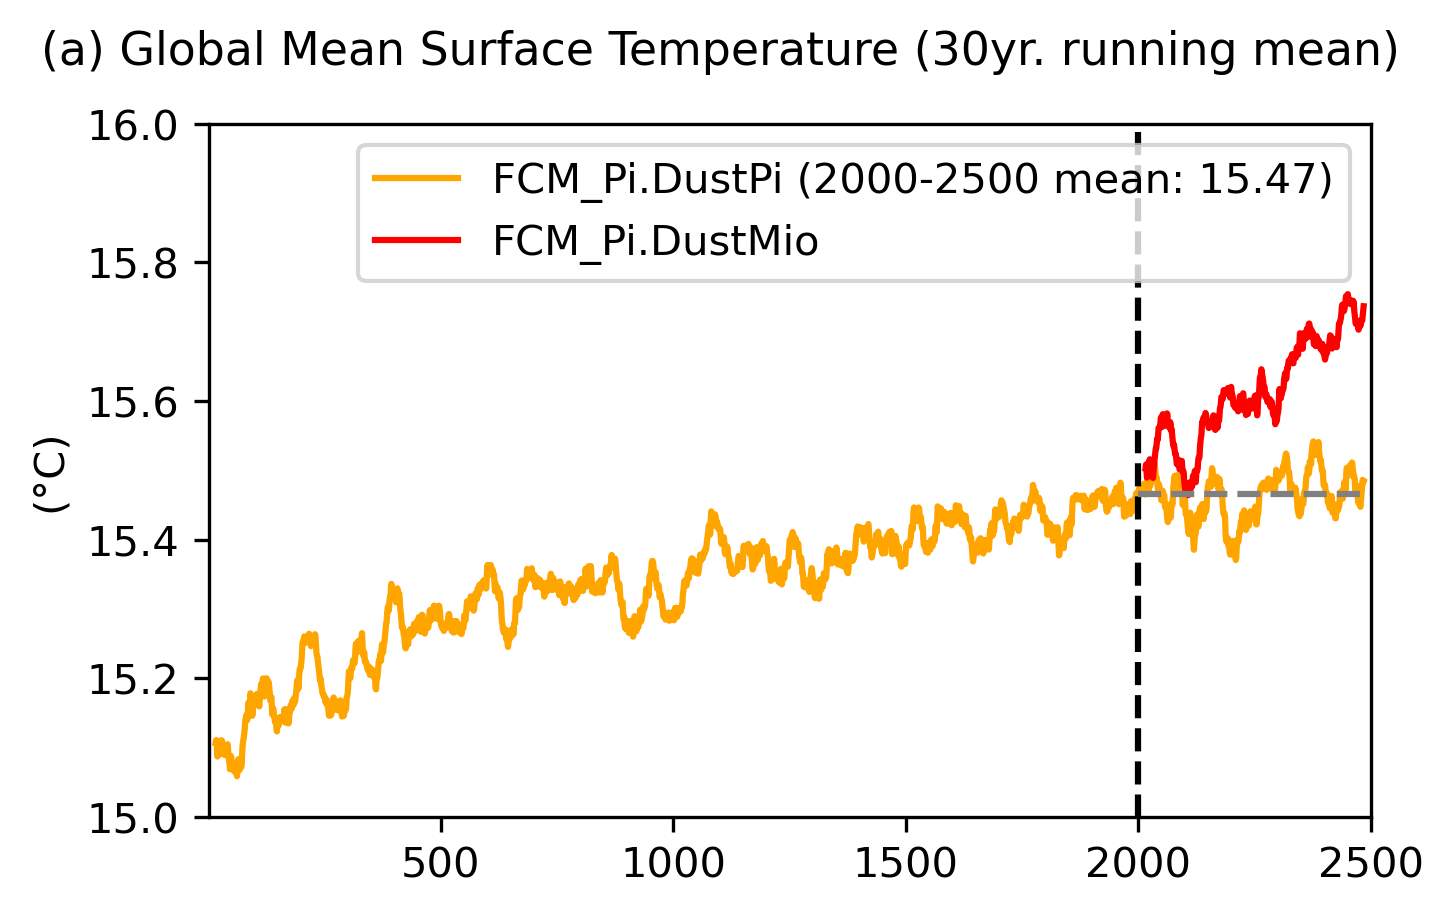

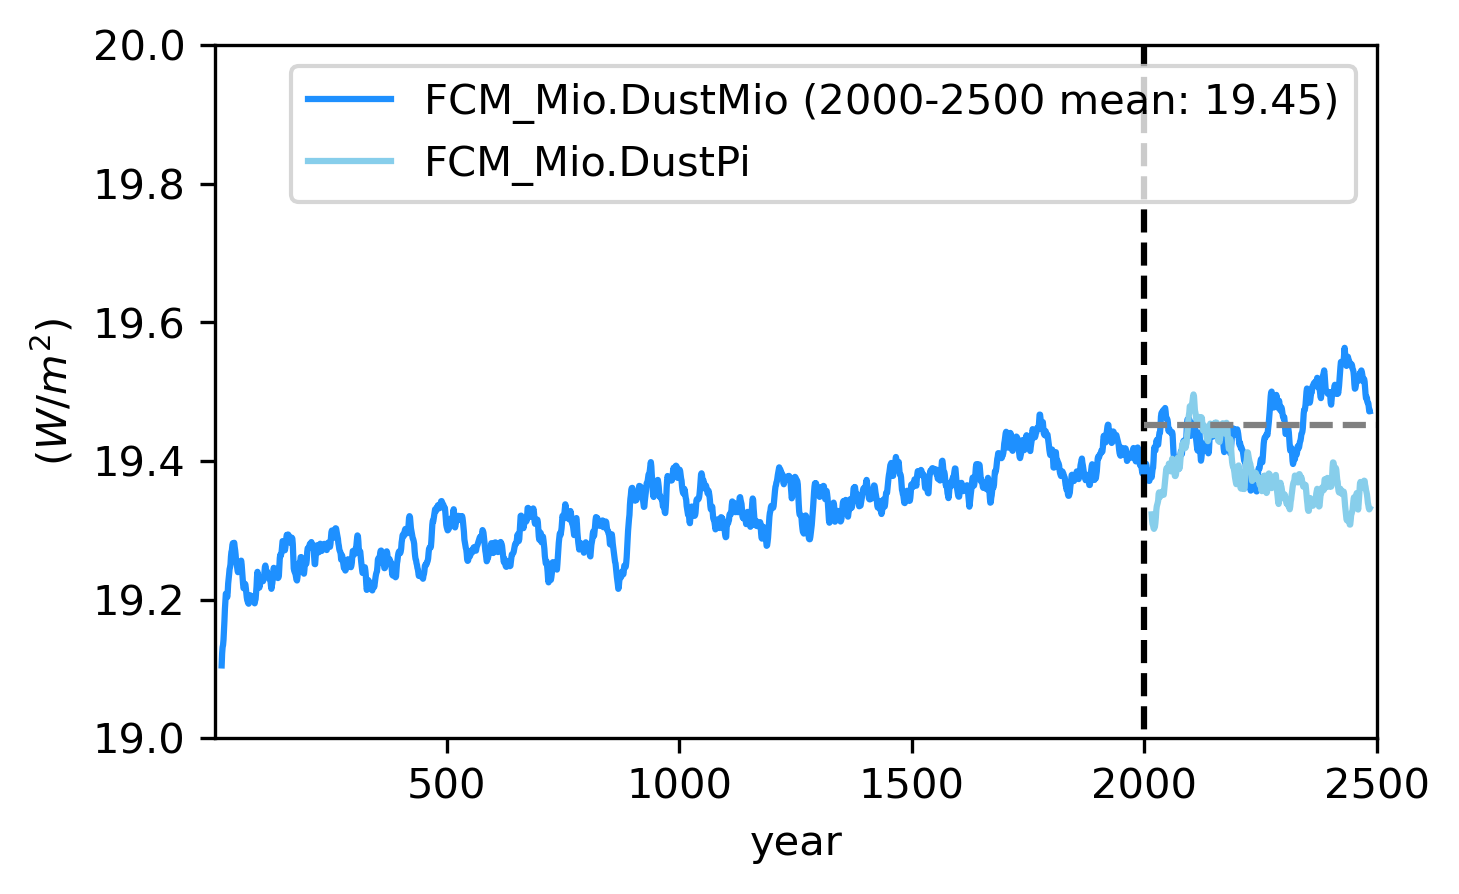

In [21]:
# ========== Global Mean Surface Temperature (30yr. running mean) ==========
# --- GeoPi

xrange = np.empty((2, ts_Pi_Pi_rmean.size))
xrange[0,:] = np.nan
xrange[1,:] = np.nan
xrange[0,:] = np.arange(1,ts_Pi_Pi_rmean.size+1,1)
xrange[1,2000:2500] = np.arange(2000+1,2000+ts_Pi_Mio_rmean.size+1,1)

# xlabel = 'year'
xlabel = ''
xticks = np.arange(0,ts_Pi_Pi_rmean.size+1,500)
xticklabels = np.arange(0,ts_Pi_Pi_rmean.size+1,500)
ylabel = '(°C)'
xmin = 1
xmax = ts_Mio_Mio_rmean.size+1
ymin = 15
ymax = 16
ts_Pi_mean = np.mean(ts_Pi_Pi[2000:2500])
legend_PP = 'FCM_Pi.DustPi (2000-2500 mean: '+str('{:03.2f}'.format(ts_Pi_mean.values))+')'
legend_PM = 'FCM_Pi.DustMio'
legend = [legend_PP,legend_PM]
colors = ['orange','r']
title = '(a) Global Mean Surface Temperature (30yr. running mean)'

yRef = [15.4, 15.4]

time_series_mean(ts_Pi_running_mean, xlabel, xticks, xticklabels, ylabel, ts_Pi_mean.values,
                 xrange, xmin, xmax, ymin, ymax, legend, colors, yRef, title)

# --- GeoMio

xrange = np.empty((2, ts_Mio_Mio_rmean.size))
xrange[0,:] = np.nan
xrange[1,:] = np.nan
xrange[0,:] = np.arange(1,ts_Mio_Mio_rmean.size+1,1)
xrange[1,2000:2500] = np.arange(2000+1,2000+ts_Mio_Pi_rmean.size+1,1)

xlabel = 'year'
xticks = np.arange(0,ts_Mio_Mio_rmean.size+1,500)
xticklabels = np.arange(0,ts_Mio_Mio_rmean.size+1,500)
ylabel = '($W/m^2$)'
xmin = 1
xmax = ts_Mio_Mio_rmean.size+1
ymin = 19
ymax = 20
ts_Mio_mean = np.mean(ts_Mio_Mio[2000:2500])
legend_MM = 'FCM_Mio.DustMio (2000-2500 mean: '+str('{:03.2f}'.format(ts_Mio_mean.values))+')'
legend_MP = 'FCM_Mio.DustPi'
legend = [legend_MM,legend_MP]
colors = ['dodgerblue','skyblue']
# title = 'Global Mean Surface Temperature (30yr. running mean)'
title = ''

yRef = [19.35, 19.35]

time_series_mean(ts_Mio_running_mean, xlabel, xticks, xticklabels, ylabel, ts_Mio_mean.values,
                 xrange, xmin, xmax, ymin, ymax, legend, colors, yRef, title)

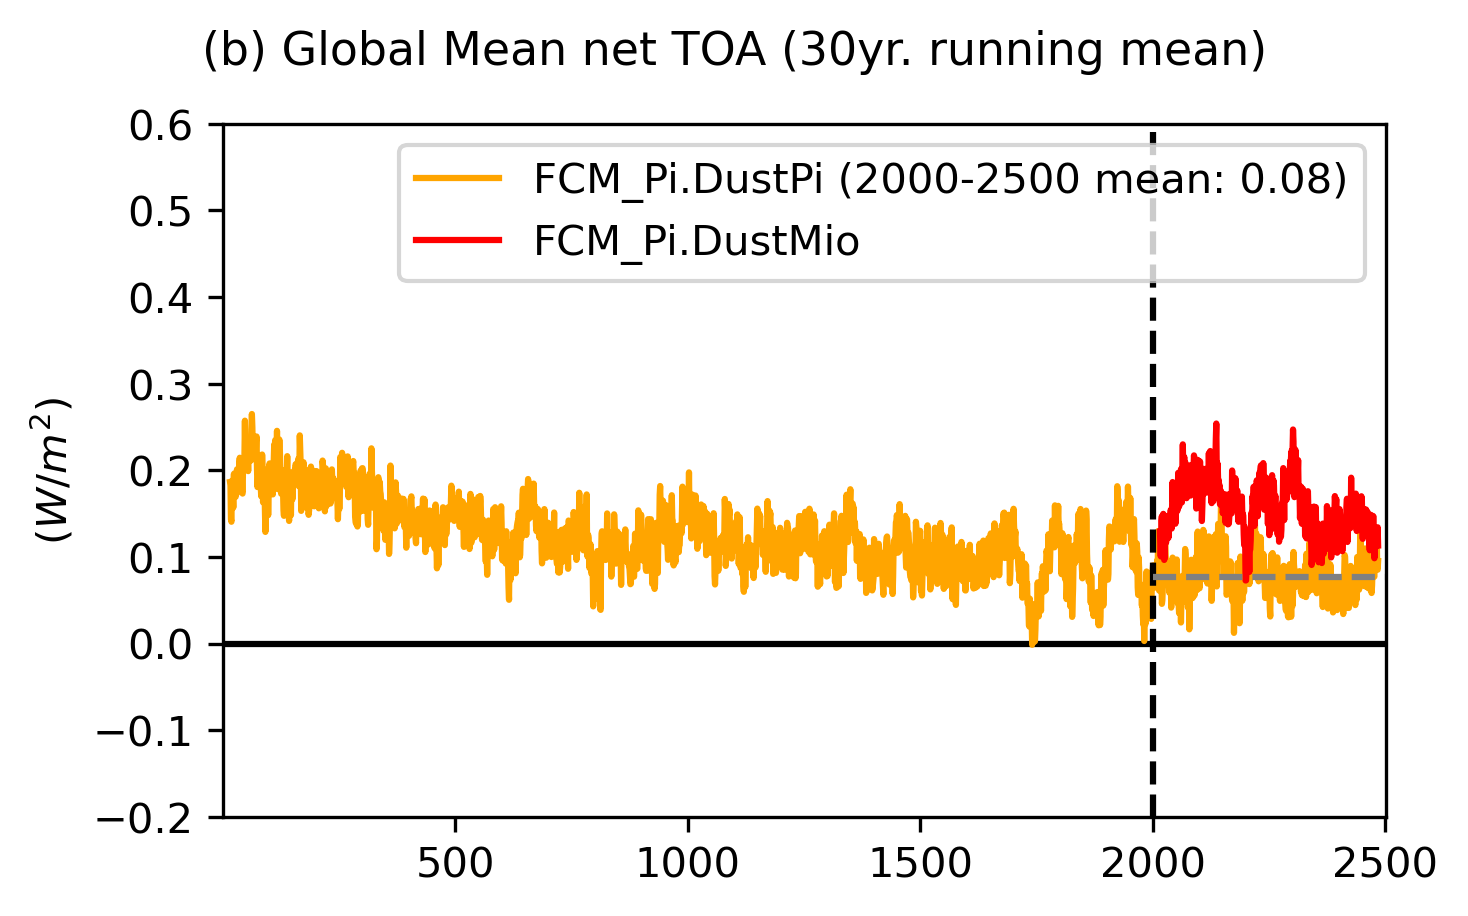

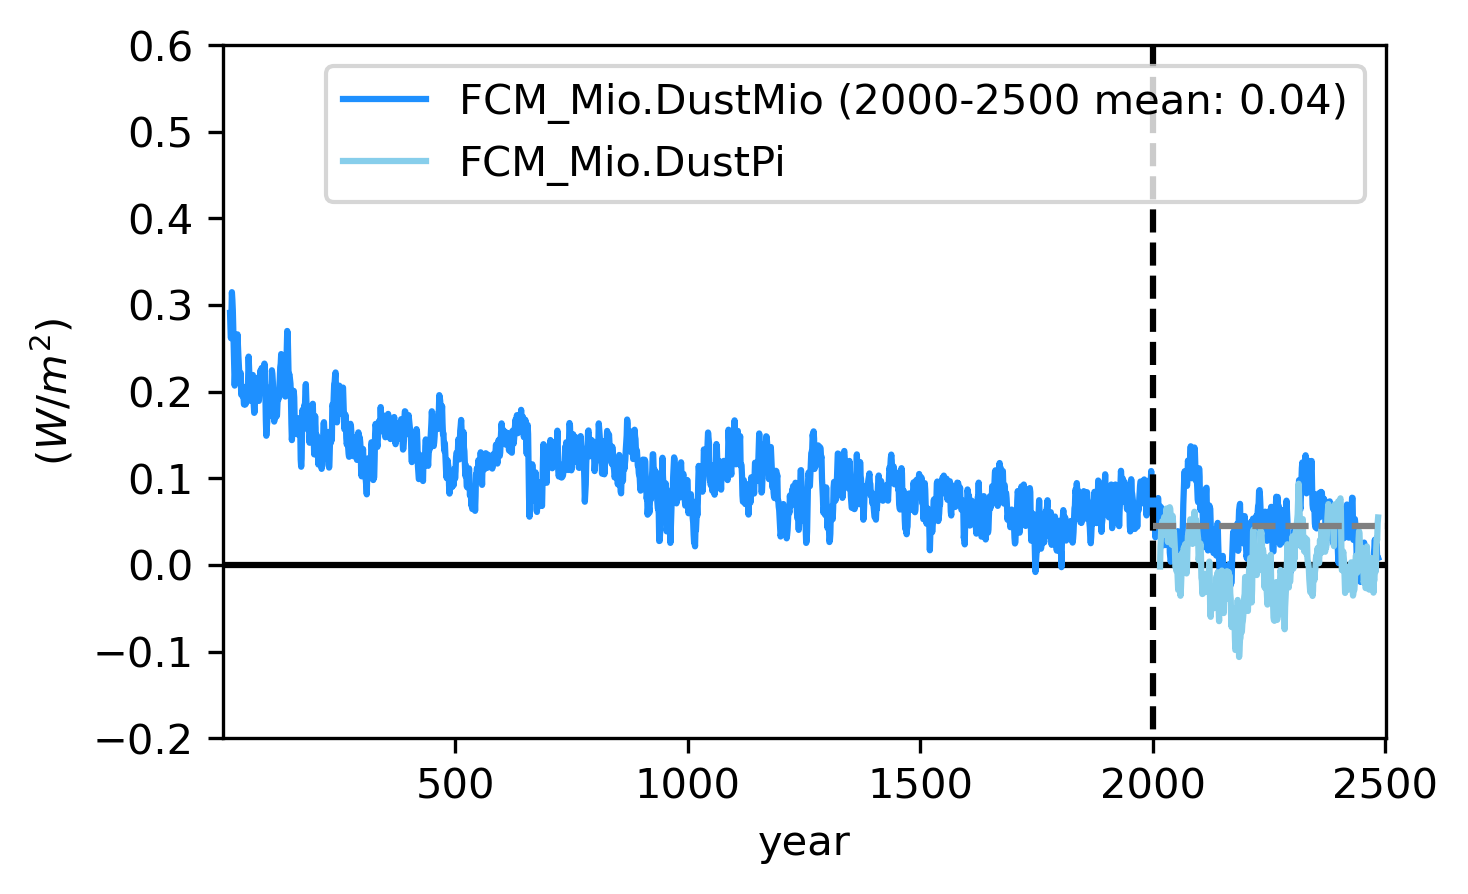

In [23]:
# ========== Global Mean net TOA radiation (30yr. running mean) ==========
# --- GeoPi

xrange = np.empty((2, toa_Pi_Pi_rmean.size))
xrange[0,:] = np.nan
xrange[1,:] = np.nan
xrange[0,:] = np.arange(1,toa_Pi_Pi_rmean.size+1,1)
xrange[1,2000:2500] = np.arange(2000+1,2000+toa_Pi_Mio_rmean.size+1,1)

# xlabel = 'year'
xlabel = ''
xticks = np.arange(0,toa_Pi_Pi_rmean.size+1,500)
xticklabels = np.arange(0,toa_Pi_Pi_rmean.size+1,500)
ylabel = '($W/m^2$)'
xmin = 1
xmax = toa_Pi_Pi_rmean.size+1
ymin = -0.2
ymax = 0.6
toa_Pi_mean = np.mean(toa_Pi_Pi[2000:2500])
legend_PP = 'FCM_Pi.DustPi (2000-2500 mean: '+str('{:03.2f}'.format(toa_Pi_mean.values))+')'
legend_PM = 'FCM_Pi.DustMio'
legend = [legend_PP,legend_PM]
colors = ['orange','r']
title = '(b) Global Mean net TOA (30yr. running mean)'

yRef = [15.4, 15.4]

time_series_mean(toa_Pi_running_mean, xlabel, xticks, xticklabels, ylabel, toa_Pi_mean.values,
                 xrange, xmin, xmax, ymin, ymax, legend, colors, yRef, title)


# --- GeoMio

xrange = np.empty((2, toa_Mio_Mio_rmean.size))
xrange[0,:] = np.nan
xrange[1,:] = np.nan
xrange[0,:] = np.arange(1,toa_Mio_Mio_rmean.size+1,1)
xrange[1,2000:2500] = np.arange(2000+1,2000+toa_Mio_Pi_rmean.size+1,1)

xlabel = 'year'
xticks = np.arange(0,toa_Mio_Mio_rmean.size+1,500)
xticklabels = np.arange(0,toa_Mio_Mio_rmean.size+1,500)
ylabel = '($W/m^2$)'
xmin = 1
xmax = toa_Mio_Mio_rmean.size+1
ymin = -0.2
ymax = 0.6
toa_Mio_mean = np.mean(toa_Mio_Mio[2000:2500])
legend_MM = 'FCM_Mio.DustMio (2000-2500 mean: '+str('{:03.2f}'.format(toa_Mio_mean.values))+')'
legend_MP = 'FCM_Mio.DustPi'
legend = [legend_MM,legend_MP]
colors = ['dodgerblue','skyblue']
# title = 'Global Mean net TOA radiation (30yr. running mean)'
title = ''

yRef = [19.35, 19.35]

time_series_mean(toa_Mio_running_mean, xlabel, xticks, xticklabels, ylabel, toa_Mio_mean.values,
                 xrange, xmin, xmax, ymin, ymax, legend, colors, yRef, title)